# 03. epitope射影で薬-疾患ペアは分離するか（Wang Fig3aの糖鎖版検証）

**問い**：Wang 2022 は「transcriptomeでは薬-疾患の逆転が見えないが、regulome（TF）に射影すると分離する」と示した。
では **epitope potential 空間に射影すると、薬-疾患ペアの分離（がん負/免疫正）は変わるのか？**

**設計**：承認薬×適応疾患ペア（VW_FIG3A_APPROVED_DRUG_MAP）について、薬シグネチャ(LINCS)と疾患シグネチャ(CREEDS)を
- ② glycogene空間（既知：分離せず）
- ③ **epitope potential空間**（step内max × step間min で49エピトープに射影）

でコサイン照合し、がん/免疫の中央値の分離を比較する。①transcriptome全遺伝子は既に≈0（notebook01/先行研究）。

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import snowflake.connector as sc

con = sc.connect(account='DUETMBM-LL33279', user='KOREEDA', role='ACCOUNTADMIN',
    warehouse='BIOINFORMATICS_XS', authenticator='SNOWFLAKE_JWT',
    private_key_file=os.path.expanduser('~/.ssh/snowflake_rsa_key.pem'))
cur = con.cursor()
def q(sql):
    df = cur.execute(sql).fetch_pandas_all(); df.columns=[c.lower() for c in df.columns]; return df
def norm_gene(g): return str(g).upper().replace('-', '_')
META_LC = {'value','canonical_smiles','cell','cmapid','compound_alias','dose',
           'inchi_key','pertid','pertname','timepoint','sample_id'}
print('connected')

connected


## 1. 承認薬-疾患ペア／薬シグネチャ／疾患シグネチャ（glycogene版と同じ組み方）

In [2]:
df_map = q('SELECT do_id, disease_name, pertname, drug_lc FROM RAW.CREEDS.VW_FIG3A_APPROVED_DRUG_MAP')
drugs_lc = sorted(df_map['drug_lc'].unique())
print(f"diseases={df_map['do_id'].nunique()} drugs={len(drugs_lc)} pairs={len(df_map)}")

inlist = ','.join("'%s'" % d.replace("'", "''") for d in drugs_lc)
df_drug = q(f'SELECT * FROM RAW.LINCS.GLYCO_GENES_WIDE WHERE LOWER("pertname") IN ({inlist})')
gene_cols = [c for c in df_drug.columns if c not in META_LC]
df_drug[gene_cols] = df_drug[gene_cols].apply(pd.to_numeric, errors='coerce')
df_drug['pert_lc'] = df_drug['pertname'].str.lower()
drug_sig = df_drug.groupby('pert_lc')[gene_cols].mean()
drug_sig.columns = [norm_gene(g) for g in drug_sig.columns]
drug_sig = drug_sig.fillna(0.0)
print('drug_sig', drug_sig.shape)

diseases=41 drugs=89 pairs=130


drug_sig (89, 385)


/var/folders/yb/qg8q9dxs50jft5_qv15b_2700000gn/T/ipykernel_29016/1842985465.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_drug['pert_lc'] = df_drug['pertname'].str.lower()


In [3]:
df_dis = q('''SELECT g.signature_id, g.gene, g.value, m.do_id
  FROM RAW.CREEDS.VW_HUMAN_DISEASE_GENES g
  JOIN RAW.CREEDS.DISEASE_SIGNATURES_META m USING (signature_id)''')
df_dis['gene'] = df_dis['gene'].map(norm_gene)
n_sig = df_dis.groupby('do_id')['signature_id'].nunique()
dis_sum = df_dis.groupby(['do_id','gene'])['value'].sum().reset_index()
dis_sum['avg'] = dis_sum['value'] / dis_sum['do_id'].map(n_sig)
dis_sig = dis_sum.pivot(index='do_id', columns='gene', values='avg').fillna(0.0)
print('dis_sig', dis_sig.shape)

dis_sig (178, 18760)


## 2. コサイン関数＋カテゴリ、② glycogene空間（ベースライン）

In [4]:
def cosine(u, v):
    nu, nv = np.linalg.norm(u), np.linalg.norm(v)
    return np.nan if nu == 0 or nv == 0 else float(np.dot(u, v)/(nu*nv))

CANCER=['cancer','carcinoma','leukemia','lymphoma','myeloma','melanoma','glioma','sarcoma','astrocytoma','adenoma','tumor','blastoma']
IMMUNE=['arthritis','psoriasis','asthma','crohn','colitis','lupus','dermatitis','inflammatory','multiple sclerosis']
def cat(name):
    n=str(name).lower()
    if any(k in n for k in CANCER): return 'cancer'
    if any(k in n for k in IMMUNE): return 'immune'
    return 'other'

def pair_cosines(D, Y):
    rows=[]
    for _, r in df_map.iterrows():
        do, dz, pl = r['do_id'], r['disease_name'], r['drug_lc']
        if pl in D.index and do in Y.index:
            rows.append((do, dz, pl, cosine(D.loc[pl].values, Y.loc[do].values)))
    return pd.DataFrame(rows, columns=['do_id','disease','drug','cos']).dropna(subset=['cos'])

common = sorted(set(drug_sig.columns) & set(dis_sig.columns))
res_gly = pair_cosines(drug_sig[common], dis_sig[common])
res_gly['cat'] = res_gly['disease'].map(cat)
print(f'glycogene空間: {len(common)}遺伝子, {len(res_gly)}ペア')
print(res_gly.groupby('cat')['cos'].median())

glycogene空間: 334遺伝子, 130ペア
cat
cancer    0.013828
immune    0.019309
other     0.006218
Name: cos, dtype: float64


## 3. ③ epitope potential 空間へ射影（step内max × step間min）

薬・疾患のシグネチャをそれぞれ49エピトープに射影 → epitopeベクトル同士でコサイン。

In [5]:
steps = q('SELECT epitope_id, epitope_name, step_id, hgnc_symbol FROM RAW.GLYCOEPITOPE.EPITOPE_STEP_GENE')
steps['hgnc_symbol'] = steps['hgnc_symbol'].map(norm_gene)
ep_steps = (steps.groupby(['epitope_id','epitope_name','step_id'])['hgnc_symbol']
            .apply(list).reset_index())

def project(sig):
    """id×gene → id×epitope（step内max, step間min, 利用可能な遺伝子のみ）"""
    out={}
    for (epid, epname), grp in ep_steps.groupby(['epitope_id','epitope_name']):
        step_vals=[]
        for _, r in grp.iterrows():
            gs=[g for g in r['hgnc_symbol'] if g in sig.columns]
            if gs: step_vals.append(sig[gs].max(axis=1))
        if step_vals:
            out[epname]=pd.concat(step_vals, axis=1).min(axis=1)
    return pd.DataFrame(out)

D_ep = project(drug_sig)
Y_ep = project(dis_sig)
ep_common = sorted(set(D_ep.columns) & set(Y_ep.columns))
D_ep, Y_ep = D_ep[ep_common], Y_ep[ep_common]
print(f'epitope空間: {len(ep_common)}エピトープ  drug{D_ep.shape} disease{Y_ep.shape}')

res_ep = pair_cosines(D_ep, Y_ep)
res_ep['cat'] = res_ep['disease'].map(cat)
print(f'{len(res_ep)}ペア')
print(res_ep.groupby('cat')['cos'].median())

epitope空間: 46エピトープ  drug(89, 46) disease(178, 46)
81ペア
cat
cancer    0.054739
immune    0.111305
other     0.052488
Name: cos, dtype: float64


## 4. 分離度の比較（②glycogene vs ③epitope）

Wangの主張＝治療ペアは負に寄る。がん(負が理想)と免疫の中央値差が大きいほど「分離した」。

In [6]:
from scipy.stats import mannwhitneyu
def summarize(res, label):
    med = res.groupby('cat')['cos'].median()
    ca = res.loc[res.cat=='cancer','cos']; im = res.loc[res.cat=='immune','cos']
    sep = med.get('immune', np.nan) - med.get('cancer', np.nan)
    try: p = mannwhitneyu(ca, im).pvalue
    except Exception: p = np.nan
    print(f'[{label}] cancer中央値={med.get("cancer",np.nan):+.3f}  immune中央値={med.get("immune",np.nan):+.3f}  '
          f'分離(免疫-がん)={sep:+.3f}  Mann-Whitney p={p:.3g}  (n_cancer={len(ca)}, n_immune={len(im)})')
    return sep, p

print('※ 分離>0（免疫>がん）かつ有意なら「射影で薬-疾患分離が出た」')
summarize(res_gly, 'glycogene')
summarize(res_ep, 'epitope')

※ 分離>0（免疫>がん）かつ有意なら「射影で薬-疾患分離が出た」
[glycogene] cancer中央値=+0.014  immune中央値=+0.019  分離(免疫-がん)=+0.005  Mann-Whitney p=0.969  (n_cancer=24, n_immune=35)
[epitope] cancer中央値=+0.055  immune中央値=+0.111  分離(免疫-がん)=+0.057  Mann-Whitney p=1  (n_cancer=19, n_immune=25)


(np.float64(0.056566448307311605), np.float64(1.0))

/var/folders/yb/qg8q9dxs50jft5_qv15b_2700000gn/T/ipykernel_29016/1565590014.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([d['cancer'], d['immune'], d['other']], labels=['cancer','immune','other'],
/var/folders/yb/qg8q9dxs50jft5_qv15b_2700000gn/T/ipykernel_29016/1565590014.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([d['cancer'], d['immune'], d['other']], labels=['cancer','immune','other'],
/var/folders/yb/qg8q9dxs50jft5_qv15b_2700000gn/T/ipykernel_29016/1565590014.py:12: UserWarning: Glyph 31354 (\N{CJK UNIFIED IDEOGRAPH-7A7A}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig('../../results/figures/fig3a_epitope_projection.png', dpi=200, bbox_inches='tight')
/var/folders/yb/q

/Users/koreedatatsuya/miniconda3/envs/glyco_pred/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31354 (\N{CJK UNIFIED IDEOGRAPH-7A7A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/koreedatatsuya/miniconda3/envs/glyco_pred/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/koreedatatsuya/miniconda3/envs/glyco_pred/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23556 (\N{CJK UNIFIED IDEOGRAPH-5C04}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/koreedatatsuya/miniconda3/envs/glyco_pred/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24433 (\N{CJK UNIFIED IDEOGRAPH-5F71}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/koreedatatsuya/mi

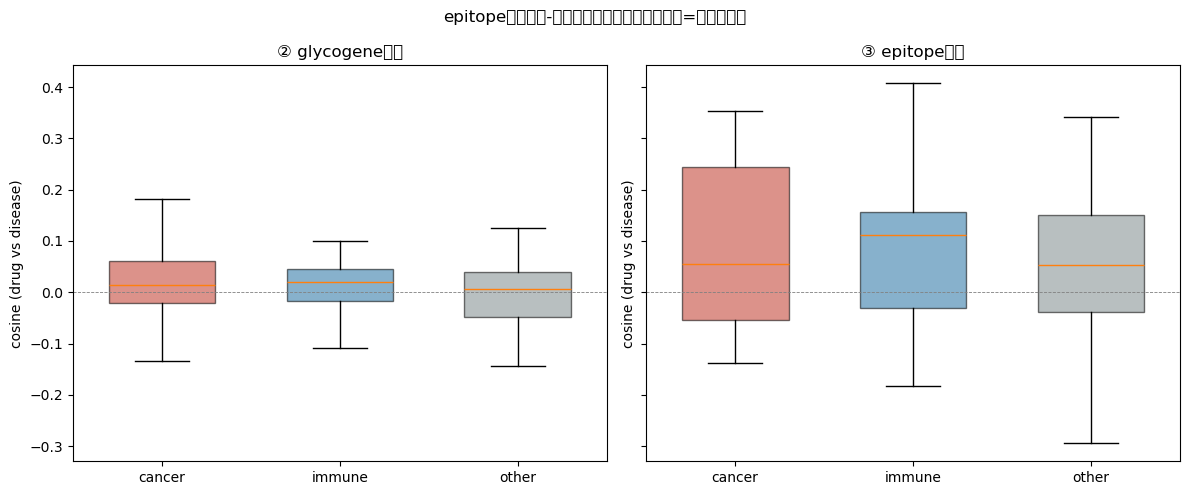

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, (res, title) in zip(axes, [(res_gly,'② glycogene空間'), (res_ep,'③ epitope空間')]):
    d = {c: res.loc[res.cat==c,'cos'].values for c in ['cancer','immune','other']}
    bp = ax.boxplot([d['cancer'], d['immune'], d['other']], labels=['cancer','immune','other'],
                    patch_artist=True, showfliers=False, widths=0.6)
    for patch, col in zip(bp['boxes'], ['#c0392b','#2471a3','#7f8c8d']):
        patch.set_facecolor(col); patch.set_alpha(0.55)
    ax.axhline(0, color='grey', lw=0.6, ls='--')
    ax.set_title(title); ax.set_ylabel('cosine (drug vs disease)')
fig.suptitle('epitope射影で薬-疾患ペアは分離するか（がん=負が理想）')
os.makedirs('../../results/figures', exist_ok=True)
fig.tight_layout(); fig.savefig('../../results/figures/fig3a_epitope_projection.png', dpi=200, bbox_inches='tight')
plt.show()

In [8]:
os.makedirs('../../results/tables', exist_ok=True)
res_ep.to_csv('../../results/tables/fig3a_epitope_correlations.csv', index=False)
print('saved fig3a_epitope_correlations.csv')
con.close()

saved fig3a_epitope_correlations.csv
